# 02 · makemore: Bigram Character Language Model

A character-level name generator, built two ways: (1) counting bigrams, (2) a single-layer neural net trained with softmax + gradient descent. Both reach the same solution.

**What I learned:** bigram statistics, negative log-likelihood loss, and how a neural net recovers the count table through optimisation.

*Dataset: `data/names.txt` (from karpathy/makemore). Following Karpathy's Zero to Hero series.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/llm-from-scratch/blob/main/02-makemore-bigram/02_makemore_bigram.ipynb)

In [ ]:
# Setup: download the dataset if it is not already present (works on Colab and locally)
import os, urllib.request
os.makedirs('../data', exist_ok=True)
if not os.path.exists('../data/names.txt'):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/karpathy/makemore/master/names.txt', '../data/names.txt')

In [ ]:
words  = open('../data/names.txt','r').read().splitlines()


In [ ]:
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [ ]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
len(words)

32033

In [ ]:
min(len(w) for w in words )

2

In [ ]:
max(len(w) for w in words)

15

In [ ]:
b = {}
for w in words:
  chs = ['<S>']+list(w)+['<E>']
  for ch1,ch2 in zip(chs,chs[1:]):
    bigram = (ch1,ch2)
    b[bigram] = b.get(bigram,0)+1



In [ ]:
 sorted(b.items(),key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch


In [ ]:
N = torch.zeros((3,3),dtype=torch.int32)

In [ ]:
N

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [ ]:
type(N)

torch.Tensor

In [ ]:
N[1,1] = 1

In [ ]:
N

tensor([[0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]], dtype=torch.int32)

In [ ]:

asci = "qwertyuiopasdfghjklzxcvbnm"
l = list(asci)
l = sorted(l)
stoi = { l[i-1]:i for i in range(0,27)}
stoi['.'] = 0
itos = { i:l for l,i in stoi.items()}


In [ ]:
stoi

{'z': 26,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 '.': 0}

In [ ]:
N = torch.zeros((27,27),dtype = torch.int32)
for w in words:
  chs = ['.']+list(w)+['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    bigram_idx1 = stoi[ch1]
    bigram_idx2 = stoi[ch2]
    N[bigram_idx1,bigram_idx2] += 1


In [ ]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

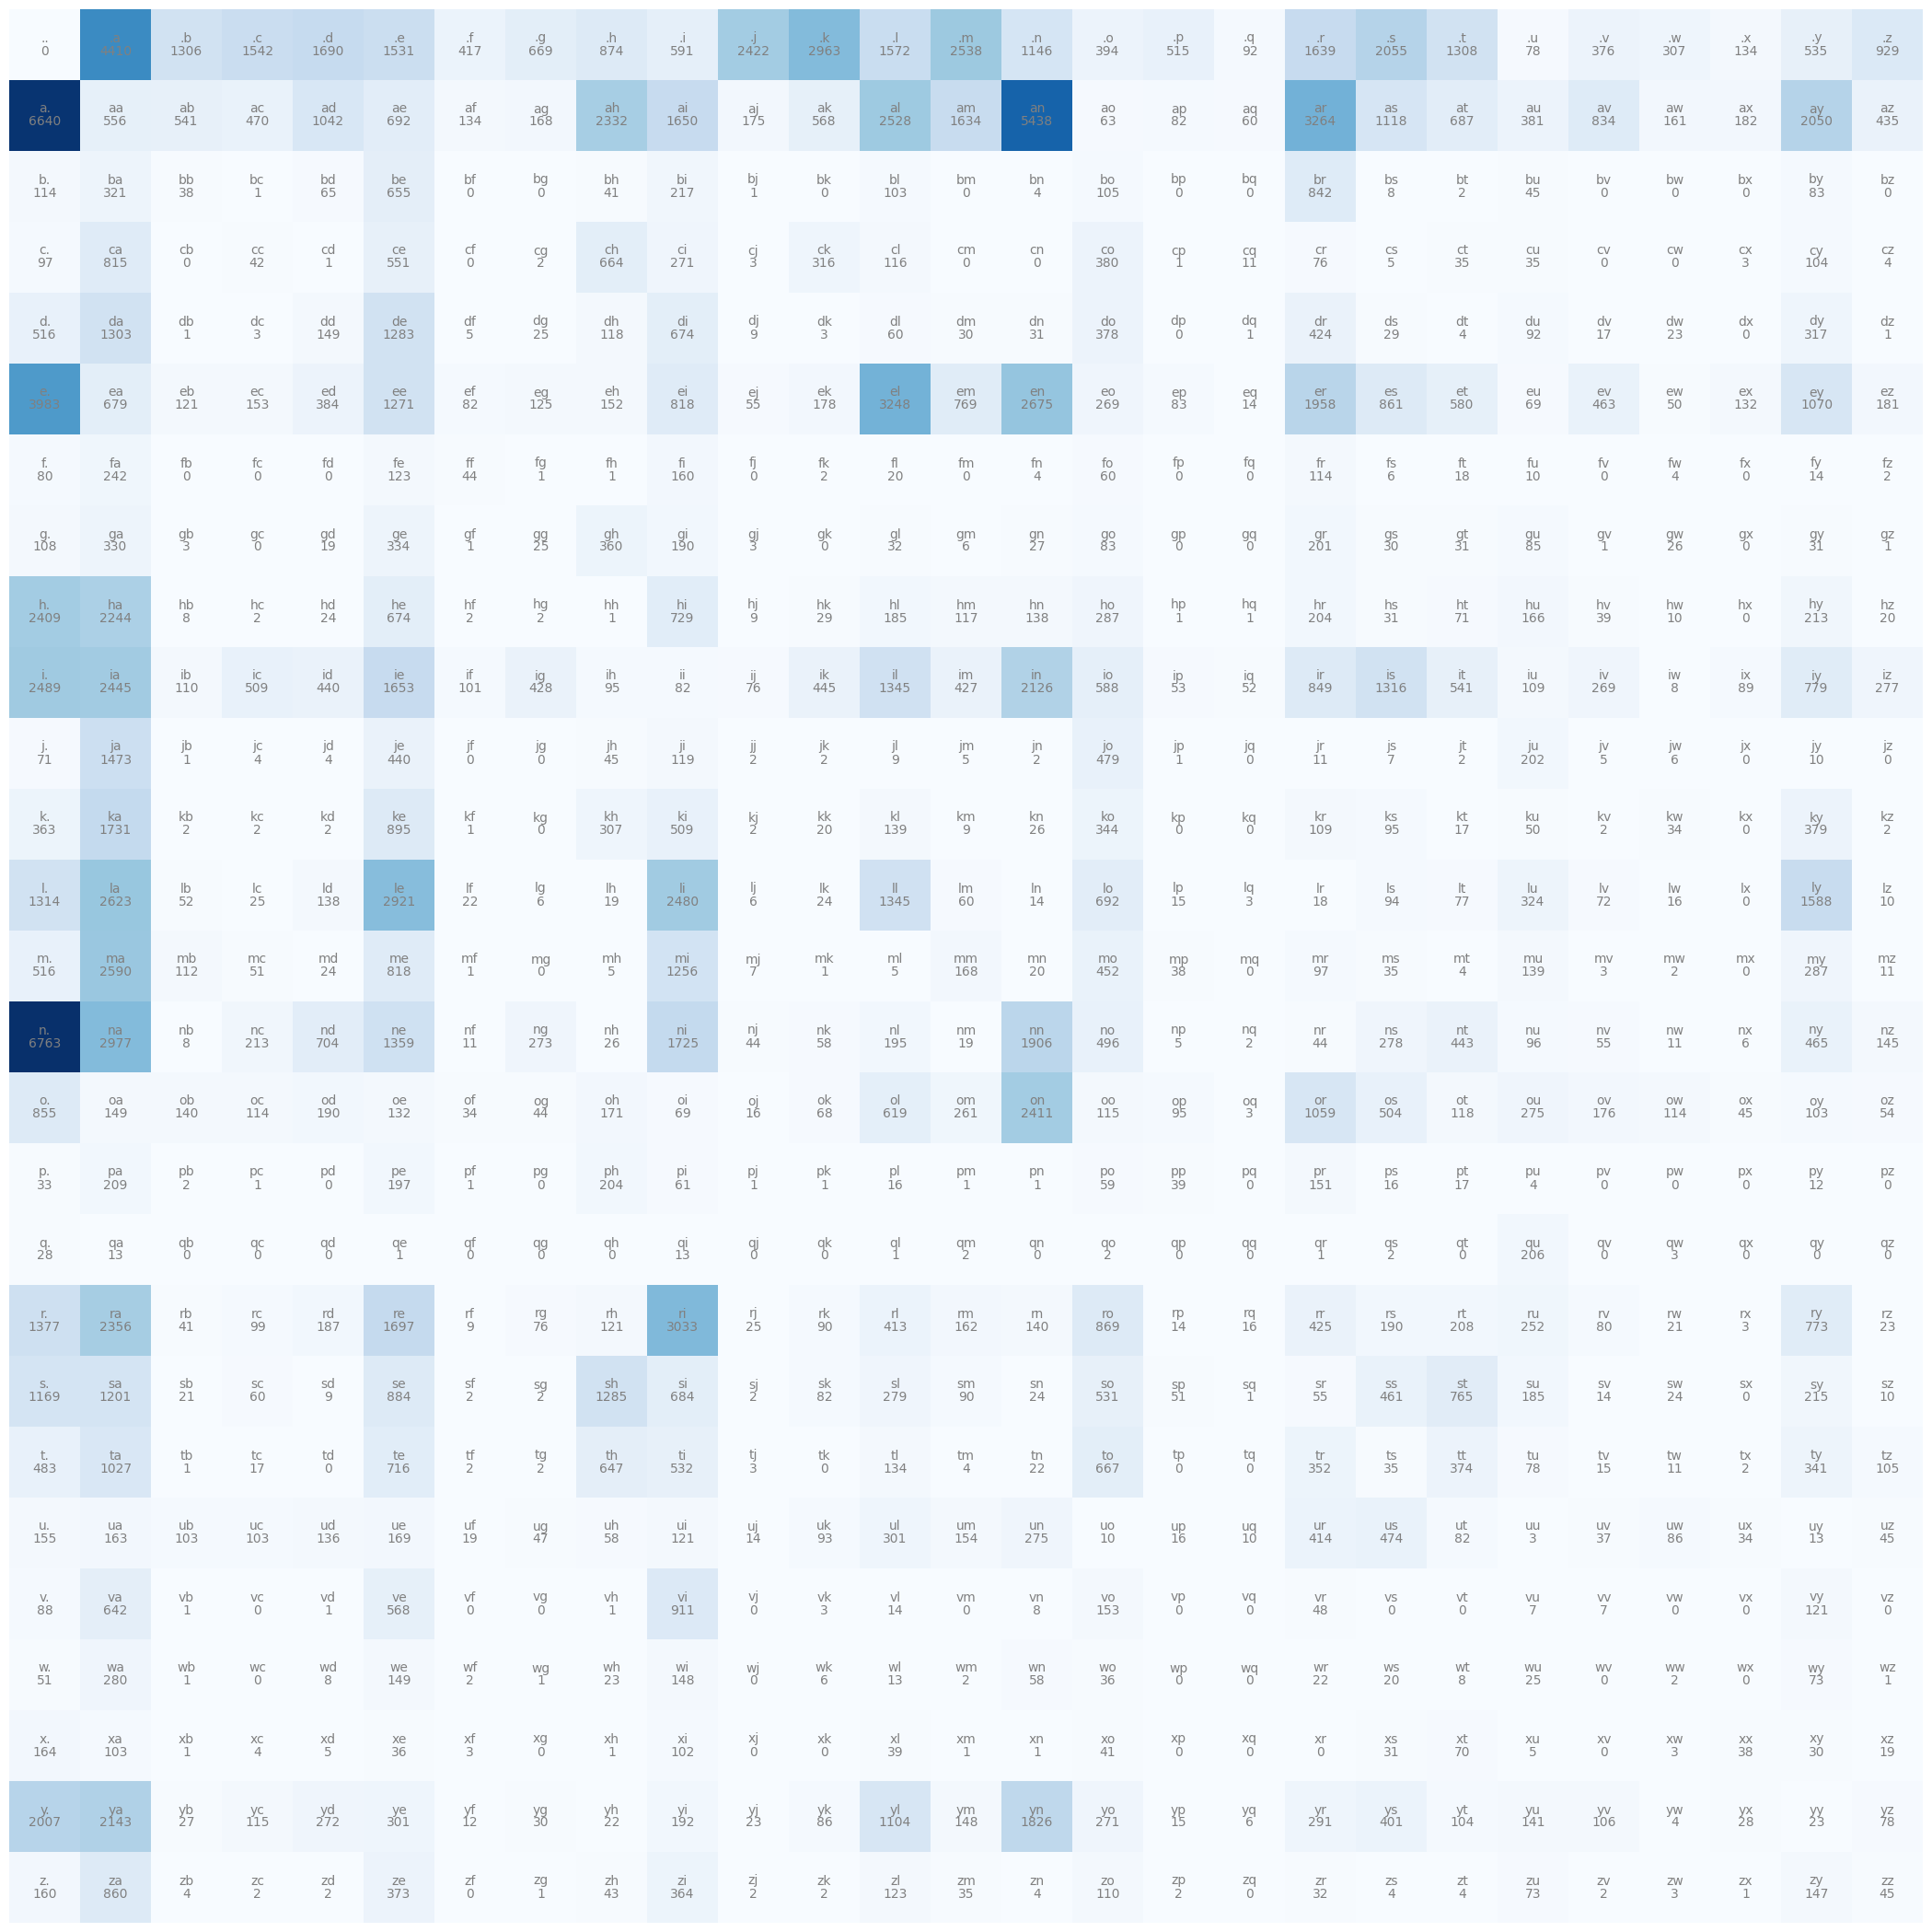

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(27,27))
plt.imshow(N,cmap='Blues')
for i in range(27):
  for j in range(27):
    charstr = itos[i]+itos[j]
    plt.text(j,i,charstr,ha='center',va='bottom',color='gray')
    plt.text(j,i,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off')

#working with softmax

## try to find out a proper W using gradient descent

In [ ]:
import torch

In [ ]:
words = open('../data/names.txt','r').read().splitlines()

In [ ]:
print(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [ ]:
chars =  set(''.join(words))
chars = sorted(list(chars))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [ ]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [ ]:
xs =[]
ys = []
for w in words:
    l = ['.']+list(w)+['.']
    for ch1,ch2 in zip(l,l[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

In [ ]:
# xs = [0,5,13,13,1]
# ys = [5,13,13,1,0]


xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
xenc = torch.nn.functional.one_hot(xs,num_classes=27).float()


In [ ]:
xenc.dtype

torch.float32

In [ ]:
xenc.shape

torch.Size([228146, 27])

In [ ]:
xenc



tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [ ]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g)

In [ ]:
W

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
          2.4968e+00,  2.4448e+00],
        [-6.7006e-01, -1.2199e+00,  3.0314e-01, -1.0725e+00,  7.2762e-01,
          5.1114e-02,  1.3095e+00, -8.0220e-01, -8.5042e-01, -1.8068e+00,
          1.2523e+00, -1.2256e+00,  1.2165e+00, -9.6478e-01, -2.3211e-01,
         -3.4762e-01,  3.3244e-01, -1.3263e+00,  1.1224e+00,  5.9641e-01,
          4.5846e-01,  5.4011e-02, -1.7400e+00,  1.1560e-01,  8.0319e-01,
          5.4108e-01, -1.1646e+00],
        [ 1.4756e-01, -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01,
         -7.8305e-01,  1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,
          9.3743e-01, -8.8303e-01,  1.74

In [ ]:
logits = xenc @ W
counts = logits.exp()
probs = counts/counts.sum(1,keepdims=True)



In [ ]:
logits.exp()

tensor([[ 4.7940,  0.7888,  0.9730,  ...,  0.9317, 12.1434, 11.5281],
        [ 1.6038,  4.4060,  1.3737,  ...,  0.6521,  0.1193,  2.6128],
        [ 1.2136,  2.8669,  1.8850,  ...,  4.6866,  1.8232,  0.4921],
        ...,
        [ 2.0989,  0.5555,  0.6281,  ...,  0.8704,  3.7049,  0.7726],
        [ 2.9062,  1.2382,  0.4649,  ...,  3.8208,  0.8046,  2.3696],
        [ 1.2415,  0.4551,  0.7189,  ...,  0.7687,  0.4699,  2.2685]])

In [ ]:
probs

tensor([[0.0607, 0.0100, 0.0123,  ..., 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248,  ..., 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484,  ..., 0.1204, 0.0469, 0.0126],
        ...,
        [0.0301, 0.0080, 0.0090,  ..., 0.0125, 0.0531, 0.0111],
        [0.0634, 0.0270, 0.0101,  ..., 0.0833, 0.0175, 0.0517],
        [0.0308, 0.0113, 0.0178,  ..., 0.0190, 0.0116, 0.0562]])

In [ ]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())


--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

#lets optimization !

In [ ]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [ ]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [ ]:
#randomly initialize 27 neuron
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g,requires_grad=True)

In [ ]:
#forward pass
xenc = torch.nn.functional.one_hot(xs,num_classes=27).float()
logits = xenc @ W #predict log-counts
counts = logits.exp() #counts, equivalent to N
probs = counts/counts.sum(1,keepdims=True)

In [ ]:
probs.shape

torch.Size([228146, 27])

In [ ]:
#loss
loss = -probs[torch.arange(probs.shape[0]),ys].log().mean()
loss

tensor(3.7590, grad_fn=<NegBackward0>)

In [ ]:
#backward
W.grad = None
loss.backward()


In [ ]:
W.data += 0.1 * W.grad

#lets run through 10 epochs

In [ ]:
for i in range(100):

  #forward pass
  xenc = torch.nn.functional.one_hot(xs,num_classes=27).float()
  logits = xenc @ W #predict log-counts
  counts = logits.exp() #counts, equivalent to N
  probs = counts/counts.sum(1,keepdims=True)

  #loss
  loss = -probs[torch.arange(probs.shape[0]),ys].log().mean()
  print(f'{i} th  interation loss:{loss}')

  #backward
  W.grad = None
  loss.backward()

  #update W.data
  W.data += -5 * W.grad

0 th  interation loss:2.585799217224121
1 th  interation loss:2.5850491523742676
2 th  interation loss:2.5843067169189453
3 th  interation loss:2.583571672439575
4 th  interation loss:2.5828444957733154
5 th  interation loss:2.5821239948272705
6 th  interation loss:2.5814108848571777
7 th  interation loss:2.580705165863037
8 th  interation loss:2.5800063610076904
9 th  interation loss:2.5793139934539795
10 th  interation loss:2.5786290168762207
11 th  interation loss:2.5779504776000977
12 th  interation loss:2.5772781372070312
13 th  interation loss:2.576612710952759
14 th  interation loss:2.575953483581543
15 th  interation loss:2.575300693511963
16 th  interation loss:2.5746545791625977
17 th  interation loss:2.5740139484405518
18 th  interation loss:2.5733792781829834
19 th  interation loss:2.572751760482788
20 th  interation loss:2.5721287727355957
21 th  interation loss:2.571512222290039
22 th  interation loss:2.570901393890381
23 th  interation loss:2.570296049118042
24 th  inter